### Vector potential of current carrying winding



Failure to parse tags from meshio.


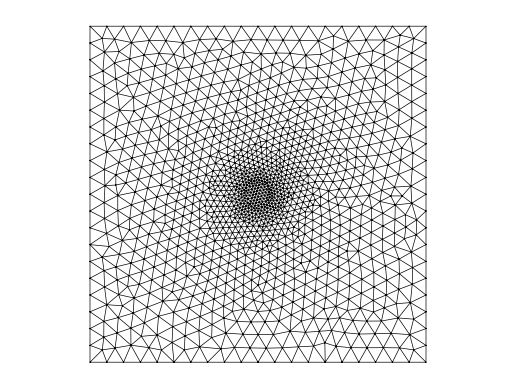

In [32]:
import meshio
from skfem import *
from skfem.helpers import dot, grad
import numpy as np

from skfem.io.meshio import from_meshio


m = meshio.read("../meshes/wire.msh")

mesh = from_meshio(m)

from skfem.visuals.matplotlib import draw
import matplotlib.pyplot as plt

draw(mesh)
plt.axis("equal")
plt.show()

Get triangualr elements and first order basis functions 

In [33]:
e = ElementTriP1()
basis = Basis(mesh, e)

print(e)
print(basis)

<skfem CellBasis(MeshTri1, ElementTriP1) object>
  Number of elements: 2460
  Number of DOFs: 1271
  Size: 531360 B


Bilinear and linear forms, from weak formulation


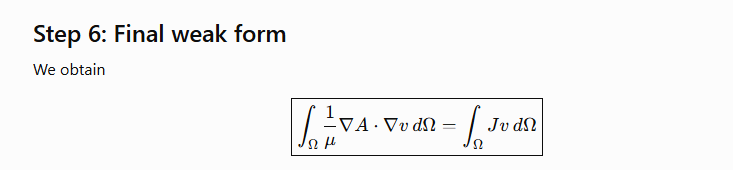

Assemble the system

In [42]:
@BilinearForm
def laplace(A, v, _):
    mu0 = 4*np.pi*1e-7
    return 1/mu0*dot(grad(A), grad(v))


@LinearForm
def rhs(v, _):
    I_z = 100
    r = 0.05
    A = np.pi*r**2
    J_z = I_z/A
    return J_z * v

S_mat = laplace.assemble(basis)
b = rhs.assemble(basis)




Add Dirichelt BC Az=0 to all boundaries. This models the air as infinitely large volume.

enforce() does the zero BC by default

In [43]:
S_mat, b = enforce(S_mat, b, D=mesh.boundary_nodes())


Solve & Visualize Az = vecotr pootential

[0.00116739 0.         0.         ... 0.00117255 0.001172   0.00117213]


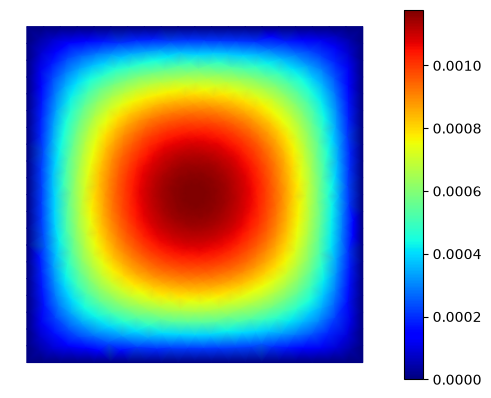

In [ ]:
A_z = solve(S_mat, b)

print(A_z)

def visualize():
    from skfem.visuals.matplotlib import plot
    return plot(mesh, A_z, shading='gouraud', colorbar=True)

if __name__ == "__main__":
    visualize().show()

Now we compute Bx and By with partial derivatives to plot B field

(2, 1271)
(3, 2460)
(2, 3, 2460)
(2, 2460)


Text(0.5, 1.0, 'B-field around wire')

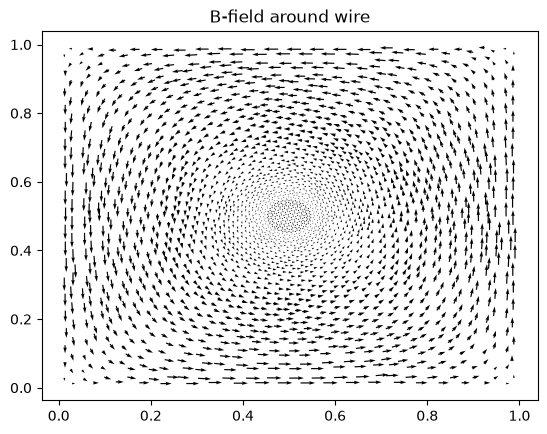

In [54]:
uh = basis.interpolate(A_z)

dAz_dx = uh.grad[0]
dAz_dy = uh.grad[1]

Bx = dAz_dy
By = -dAz_dx

Bx_elem = Bx.mean(axis=1)
By_elem = By.mean(axis=1)

centers = mesh.p[:, mesh.t].mean(axis=2)

print(mesh.p.shape)
print(mesh.t.shape)

print(mesh.p[:, mesh.t].shape)
centers = mesh.p[:, mesh.t].mean(axis=1)
print(centers.shape)

plt.quiver(
    centers[0],
    centers[1],
    Bx_elem,
    By_elem
)

plt.title("B-field around wire")



Compute B-norm and plot



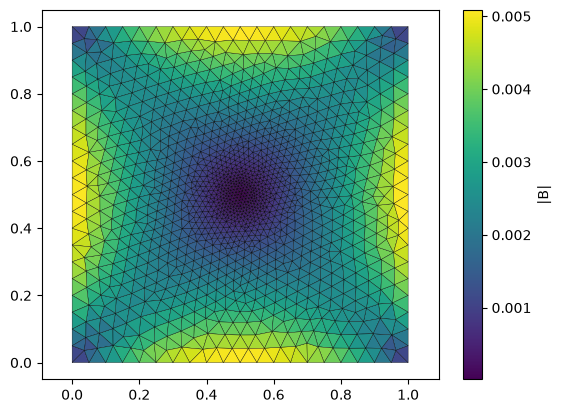

In [63]:
B_norm = np.sqrt(Bx_elem**2 + By_elem**2)

import matplotlib.pyplot as plt
import matplotlib.tri as tri

triang = tri.Triangulation(
    mesh.p[0],
    mesh.p[1],
    mesh.t.T
)

plt.tripcolor(
    triang,
    facecolors=B_norm,
    edgecolors='k'
)

plt.colorbar(label='|B|')
plt.axis('equal')
plt.show()